### Purpose: 
Funnel and engagement analysis on RetailRocket events.

Read data from `marts.fact_events` and `staging.stg_events`

In [6]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from dotenv import load_dotenv
import os

load_dotenv()

BASE_DIR = Path.cwd().parent

# Read environment variables
db_path_env = os.getenv("DB_PATH")

if db_path_env is None:
    raise ValueError("DB_PATH not found in .env")

DB_PATH = BASE_DIR / db_path_env

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")

con = duckdb.connect(str(DB_PATH), read_only=True)

### Chart - Event volume over time

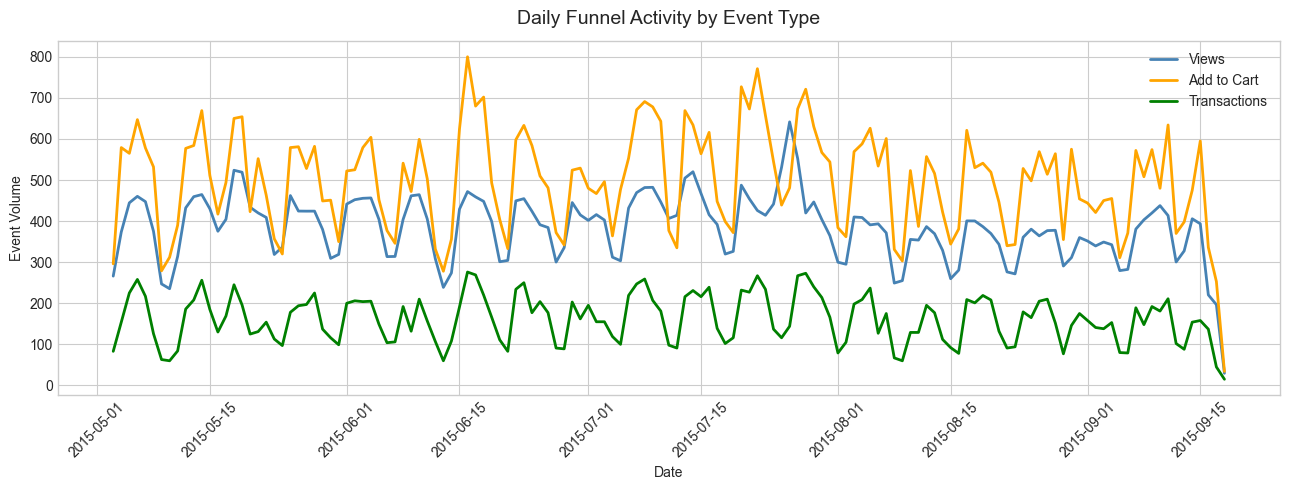

In [7]:
df = con.execute("""
    SELECT
        event_date,
        total_views,
        total_addtocarts,
        total_transactions
    FROM marts.fact_events
    ORDER BY event_date
""").df()

df['views_scaled'] = df['total_views'] / 50

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(
    df['event_date'],
    df['views_scaled'],
    label='Views',
    linewidth=2,
    color='steelblue'
)

ax.plot(
    df['event_date'],
    df['total_addtocarts'],
    label='Add to Cart',
    linewidth=2,
    color='orange'
)

ax.plot(
    df['event_date'],
    df['total_transactions'],
    label='Transactions',
    linewidth=2,
    color='green'
)

ax.set_title(
    'Daily Funnel Activity by Event Type',
    fontsize=14,
    pad=12
)

ax.set_xlabel('Date')
ax.set_ylabel('Event Volume')

ax.legend()

plt.xticks(rotation=45)

plt.tight_layout()

output_dir = BASE_DIR / "dashboard" / "screenshots"
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "event_volume.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

`Product views consistently exceed completed purchases, highlighting substantial conversion drop-off across the ecommerce funnel. Improving add-to-cart and checkout conversion efficiency may drive more growth than increasing traffic acquisition alone.`

### Chart - views vs purchases top products

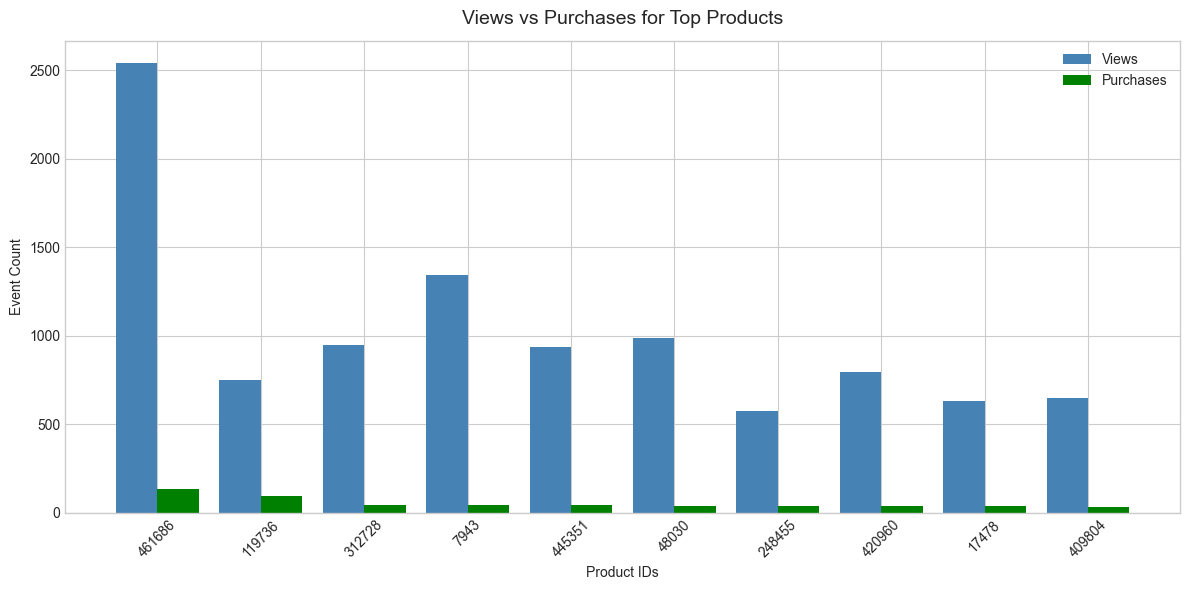

In [8]:
df = con.execute("""
    WITH product_events AS (
        SELECT
            item_id,

            SUM(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS views,

            SUM(CASE WHEN event_type = 'transaction' THEN 1 ELSE 0 END) AS purchases

        FROM staging.stg_events

        GROUP BY 1
    )

    SELECT
        item_id,
        views,
        purchases

    FROM product_events

    WHERE views > 500

    ORDER BY purchases DESC

    LIMIT 10
""").df()

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(df))

width = 0.4

ax.bar(
    [i - width/2 for i in x],
    df['views'],
    width=width,
    label='Views',
    color='steelblue'
)

ax.bar(
    [i + width/2 for i in x],
    df['purchases'],
    width=width,
    label='Purchases',
    color='green'
)

ax.set_xticks(x)
ax.set_xticklabels(df['item_id'].astype(str), rotation=45)

ax.set_title(
    'Views vs Purchases for Top Products',
    fontsize=14,
    pad=12
)

ax.set_xlabel('Product IDs')
ax.set_ylabel('Event Count')

ax.legend()

plt.tight_layout()

output_dir = BASE_DIR / "dashboard" / "screenshots"
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "views_vs_purchases.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

`Highly viewed products do not always generate strong purchase activity, highlighting conversion gaps between customer interest and completed transactions.`

### Chart - Conversion rate by event transition

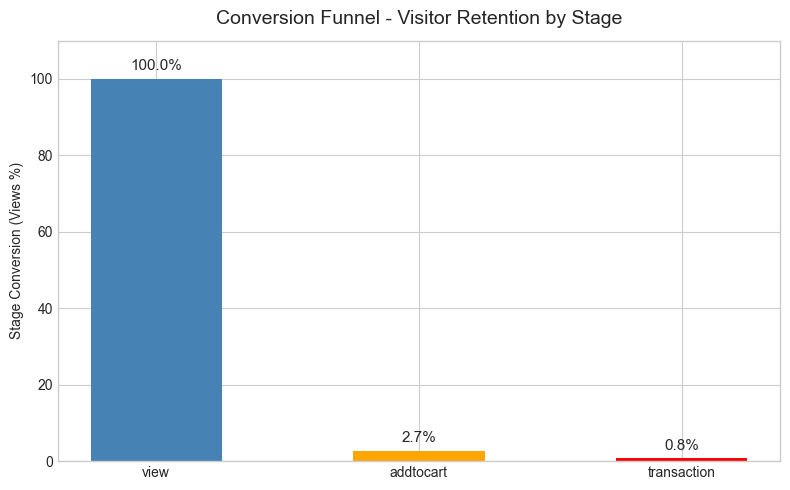

In [9]:
df = con.execute("""
    SELECT
        event_type,
        COUNT(DISTINCT visitor_id) AS visitors
    FROM staging.stg_events
    GROUP BY 1
""").df()

stage_order = ['view', 'addtocart', 'transaction']

df['event_type'] = pd.Categorical(
    df['event_type'],
    categories=stage_order,
    ordered=True
)

df = df.sort_values('event_type')

# Calculate percentage relative to views
base = df['visitors'].iloc[0]

df['pct_of_views'] = (
    df['visitors'] / base * 100
).round(1)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    df['event_type'],
    df['pct_of_views'],
    color=['steelblue', 'orange', 'red'],
    width=0.5
)

# Label percentages
ax.bar_label(
    bars,
    fmt='%.1f%%',
    padding=4,
    fontsize=11
)

ax.set_title(
    'Conversion Funnel - Visitor Retention by Stage',
    fontsize=14,
    pad=12
)

ax.set_ylabel('Stage Conversion (Views %)')

ax.set_ylim(0, 110)

plt.tight_layout()

output_dir = BASE_DIR / "dashboard" / "screenshots"
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "funnel.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

`Most visitors drop off after the product view stage, indicating major conversion gaps in add-to-cart and checkout behavior. The stage with the lowest conversion rate should receive product, UX, and pricing attention first.`

### Chart - Peak activity heatmap (hour × weekday)

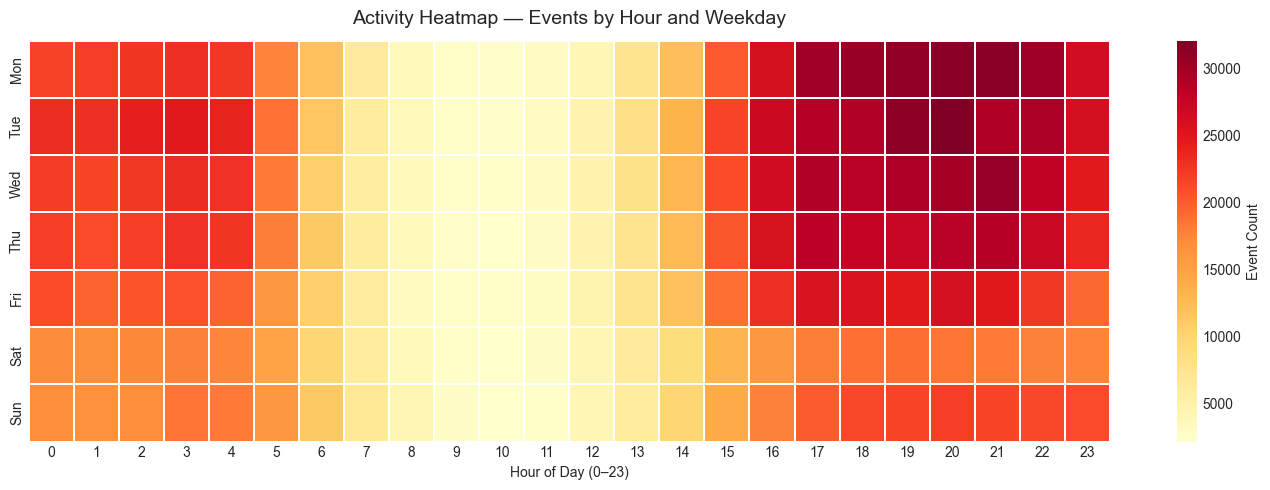

In [10]:
df = con.execute("""
    SELECT
        DAYOFWEEK(event_datetime) AS day_num,

        HOUR(event_datetime) AS hour,

        COUNT(*) AS event_count

    FROM staging.stg_events

    GROUP BY 1, 2
""").df()

day_labels = {
    0: 'Sun',
    1: 'Mon',
    2: 'Tue',
    3: 'Wed',
    4: 'Thu',
    5: 'Fri',
    6: 'Sat'
}

df['day_name'] = df['day_num'].map(day_labels)

pivot = df.pivot(
    index='day_name',
    columns='hour',
    values='event_count'
).fillna(0)

ordered_days = [
    'Mon',
    'Tue',
    'Wed',
    'Thu',
    'Fri',
    'Sat',
    'Sun'
]

pivot = pivot.reindex(
    [d for d in ordered_days if d in pivot.index]
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    pivot,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    annot=False,
    cbar_kws={'label': 'Event Count'}
)

ax.set_title(
    'Activity Heatmap — Events by Hour and Weekday',
    fontsize=14,
    pad=12
)

ax.set_xlabel('Hour of Day (0–23)')
ax.set_ylabel('')

plt.tight_layout()

output_dir = BASE_DIR / "dashboard" / "screenshots"
output_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    output_dir / "activity_heatmap.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

`Peak activity concentrates in weekday business hours - suggesting a B2C audience that browses at work. Flash promotions and email sends should target Tue–Thu 10–14h for maximum visibility.`